# **INSTAGRAM POST ENGAGEMENT ANALYSIS**

Name: Devanshi Verma 

 DATA SCIENCE PROJECT 
 
 Submitted to: Dr. Charul Nigam

# **OBJECTIVES**

1. To analyze Instagram posts of MAIMS Delhi for the year 2025 using key metrics like likes, comments, shares, and views.

2. To compare the performance of different content types such as reels, images, and carousel posts.

3. To study audience behavior through gender-based engagement 
.

4. To identify high-performing (viral) and low-performing posts to improve content strategy.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("../data/instagramdatamaims.xlsx")
df.head()

,post_id,date,post_type,likes,comments,shares,views,male_engagement,female_engagement,Hashtags_Count
0,P001,2025-01-01,image,80.0,3.0,1.0,600.0,45.0,35.0,1
1,P002,2025-01-03,reel,900.0,40.0,100.0,12000.0,500.0,400.0,8
2,P003,2025-01-05,carousel,200.0,10.0,12.0,1500.0,120.0,80.0,12
3,P004,2025-01-07,image,60.0,2.0,0.0,500.0,35.0,25.0,24
4,P005,2025-01-10,reel,1100.0,55.0,150.0,15000.0,600.0,500.0,15


In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   post_id            100 non-null    str           
 1   date               100 non-null    datetime64[us]
 2   post_type          100 non-null    str           
 3   likes              100 non-null    float64       
 4   comments           100 non-null    float64       
 5   shares             100 non-null    float64       
 6   views              100 non-null    float64       
 7   male_engagement    100 non-null    float64       
 8   female_engagement  100 non-null    float64       
 9   Hashtags_Count     145 non-null    int64         
dtypes: datetime64[us](1), float64(6), int64(1), str(2)
memory usage: 11.5 KB


,date,likes,comments,shares,views,male_engagement,female_engagement,Hashtags_Count
count,100,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,145.000000
mean,2025-05-31 03:50:24,1800.600000,129.400000,354.190000,20936.000000,974.90000,825.700000,14.406897
min,2025-01-01 00:00:00,40.000000,1.000000,0.000000,300.000000,25.00000,15.000000,0.000000
25%,2025-03-17 06:00:00,75.000000,3.000000,1.000000,600.000000,45.00000,30.000000,7.000000
50%,2025-05-31 00:00:00,925.000000,67.500000,135.000000,8250.000000,510.00000,415.000000,14.000000
75%,2025-08-14 18:00:00,2550.000000,190.000000,450.000000,32500.000000,1425.00000,1200.000000,21.000000
max,2025-10-29 00:00:00,7500.000000,600.000000,2200.000000,95000.000000,4000.00000,3500.000000,29.000000
std,NaN,2114.081609,161.876371,517.738023,26909.172031,1130.82007,984.076509,8.195101


In [90]:
df.drop_duplicates(inplace=True)



In [ ]:

df['Age_Group'] = np.random.choice(['18-24','25-34','35-44'], len(df))

df['Save_Count'] = np.random.randint(10,500,len(df))

df['Follower_Gain'] = (df['likes']*0.02 + df['shares']*0.05)

In [91]:
df['Day'] = df['date'].dt.day_name()
df['Month'] = df['date'].dt.month_name()
df['Posting_Hour'] = np.random.randint(0,24,len(df))

In [94]:
df['date'] = pd.to_datetime(df['date'])

df['Engagement'] = df['likes'] + df['comments'] + df['shares']

followers = 12560
df['Engagement_rate'] = df['Engagement'] / followers

df.isnull().sum()

post_id              24
date                 24
post_type            24
likes                24
comments             24
shares               24
views                24
male_engagement      24
female_engagement    24
Hashtags_Count        0
Engagement           24
Engagement_rate      24
Day                  24
Month                24
Posting_Hour          0
Age_Group             0
Caption_Length        0
Save_Count            0
Impressions          24
Follower_Gain        24
sample_comment        0
likes_range          24
dtype: int64

### **DISTRIBUTION (LIKES)**

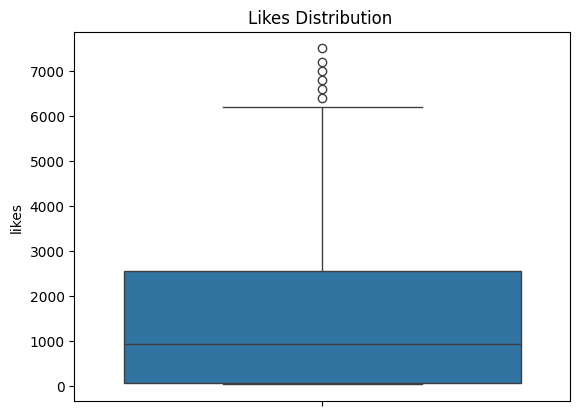

In [62]:
sns.boxplot(y=df['likes'])
plt.title("Likes Distribution ")
plt.show()

### **ENGAGEMENT AND LIKES**

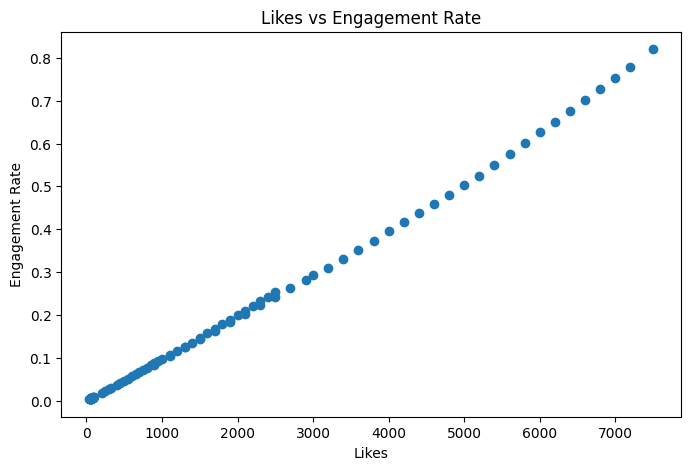

In [63]:

plt.figure(figsize=(8,5))
plt.scatter(df['likes'], df['Engagement_rate'])
plt.title("Likes vs Engagement Rate")
plt.xlabel("Likes")
plt.ylabel("Engagement Rate")
plt.show()

### **Engagement by post type**

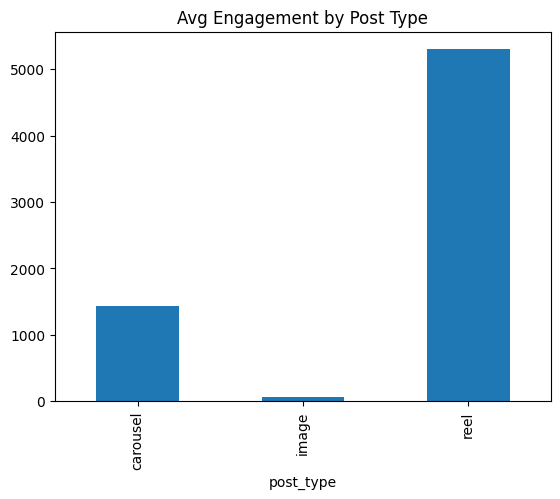

In [17]:
df.groupby('post_type')['Engagement'].mean().plot(kind='bar')
plt.title("Avg Engagement by Post Type")
plt.show()

### **Best day to post**

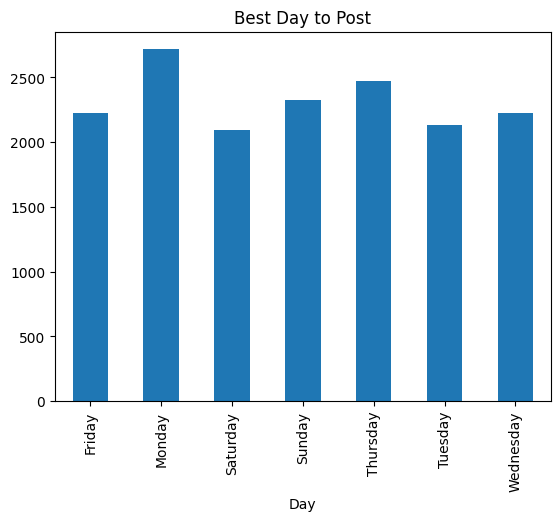

In [23]:
df.groupby('Day')['Engagement'].mean().plot(kind='bar')
plt.title("Best Day to Post")
plt.show()

### **Monthly Engagement**

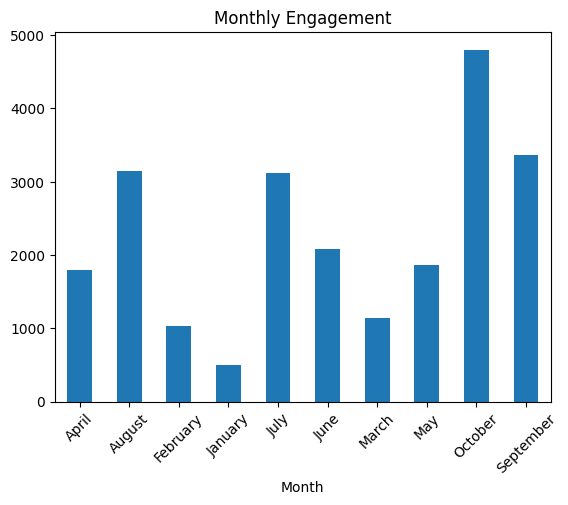

In [24]:
df.groupby('Month')['Engagement'].mean().plot(kind='bar')
plt.xticks(rotation=45)
plt.title("Monthly Engagement")
plt.show()

### **Best time to post**

C:\Users\SAI ADVISORS\AppData\Local\Temp\ipykernel_17152\1147450590.py:13: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\SAI ADVISORS\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


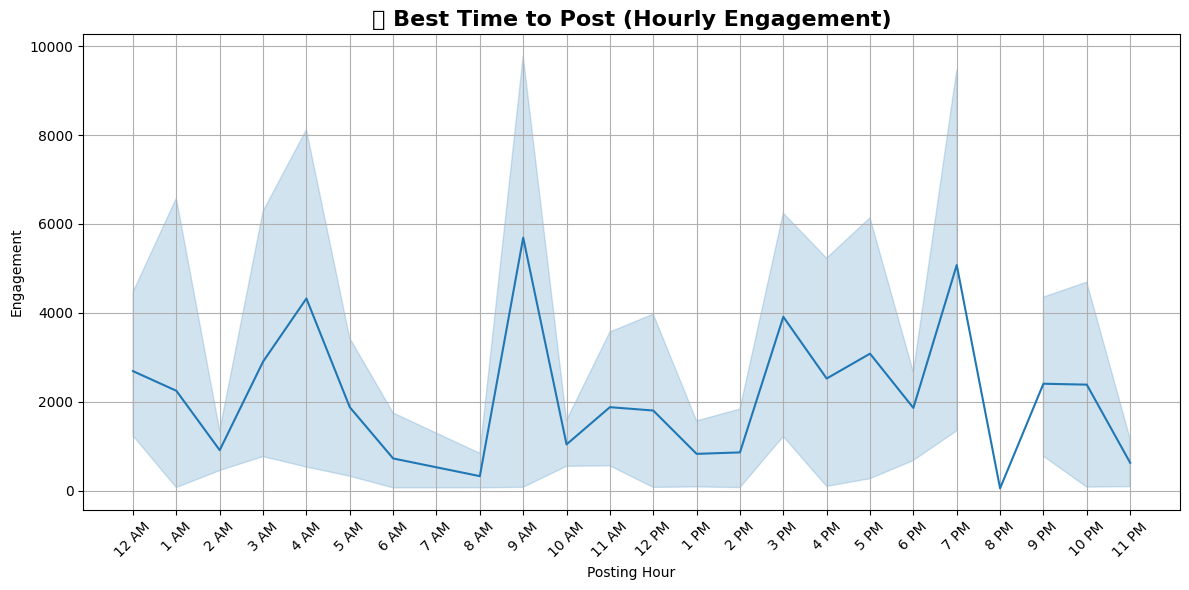

In [89]:

plt.figure(figsize=(12,6))

sns.lineplot(x='Posting_Hour', y='Engagement', data=df)

labels = [f"{h%12 if h%12!=0 else 12} {'AM' if h<12 else 'PM'}" for h in sorted(df['Posting_Hour'].unique())]
plt.xticks(sorted(df['Posting_Hour'].unique()), labels, rotation=45)

plt.title("📊 Best Time to Post (Hourly Engagement)", fontsize=16, weight='bold')
plt.xlabel("Posting Hour")
plt.ylabel("Engagement")

plt.grid(True)
plt.tight_layout()

plt.show()

### **Follower gain in a month**

<Axes: xlabel='Month'>

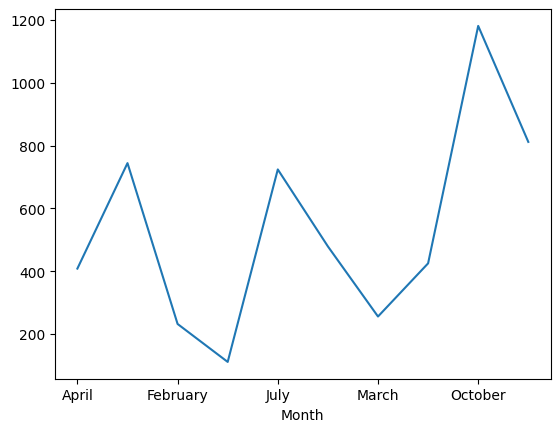

In [48]:
df.groupby('Month')['Follower_Gain'].sum().plot()

### **Likes VS Saves**

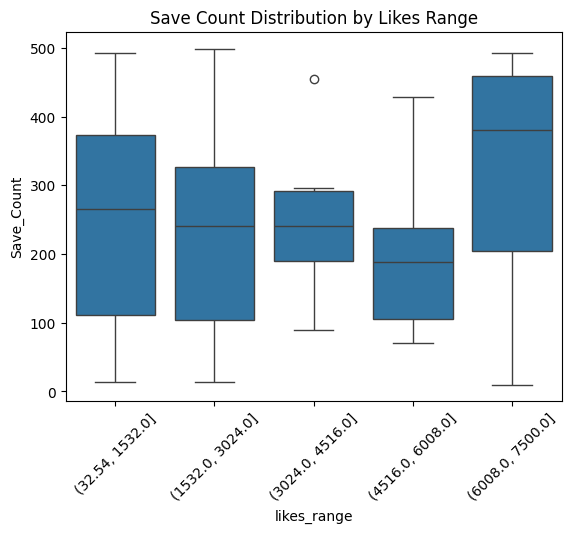

In [88]:
df['likes_range'] = pd.cut(df['likes'], bins=5)

sns.boxplot(x='likes_range', y='Save_Count', data=df)

plt.xticks(rotation=45)
plt.title("Save Count Distribution by Likes Range")

plt.show()

### **Age group vs Engagement**

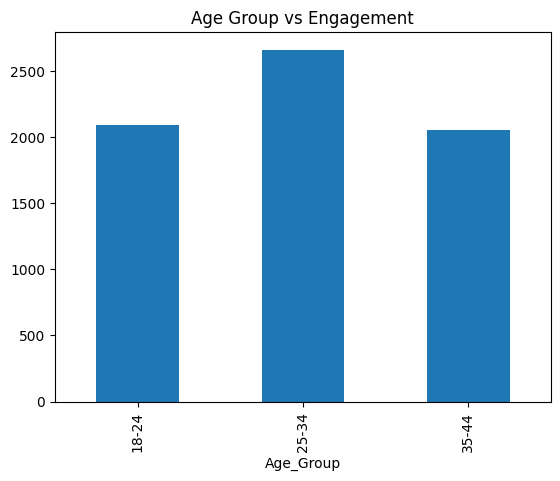

In [26]:
df.groupby('Age_Group')['Engagement'].mean().plot(kind='bar')
plt.title("Age Group vs Engagement")
plt.show()

### **Engagement and follower gain**

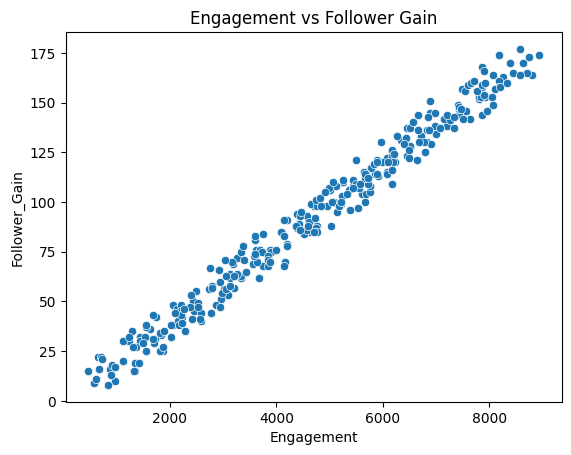

In [31]:
sns.scatterplot(x='Engagement', y='Follower_Gain', data=df)
plt.title("Engagement vs Follower Gain")
plt.show()

### **Views and likes**

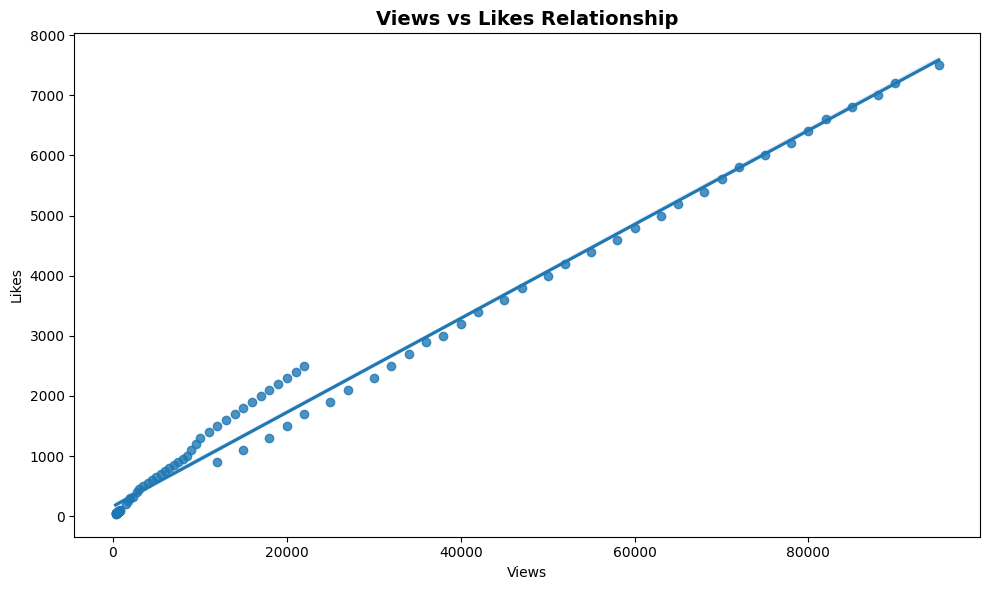

In [86]:

plt.figure(figsize=(10,6))

sns.regplot(x='views', y='likes', data=df)

plt.title("Views vs Likes Relationship", fontsize=14, weight='bold')
plt.xlabel("Views")
plt.ylabel("Likes")

plt.tight_layout()
plt.show()

### **HASHTAGS IMPACT**

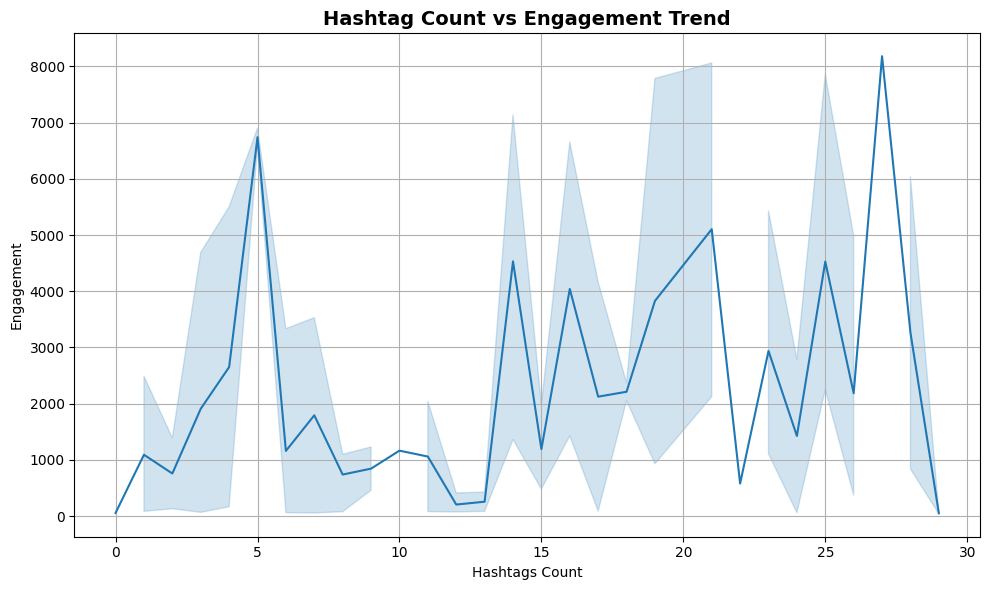

In [85]:
plt.figure(figsize=(10,6))

sns.lineplot(x='Hashtags_Count', y='Engagement', data=df)

plt.title("Hashtag Count vs Engagement Trend", fontsize=14, weight='bold')
plt.xlabel("Hashtags Count")
plt.ylabel("Engagement")

plt.grid(True)
plt.tight_layout()

plt.savefig("../output/hashtags.png")
plt.show()

### **TOP POSTS**

In [84]:
top_posts = df.nlargest(10, 'Engagement')
top_posts[['post_id','Engagement']]


,post_id,Engagement
99,P100,10300.0
96,P097,9780.0
93,P094,9460.0
90,P091,9140.0
87,P088,8820.0
84,P085,8500.0
81,P082,8180.0
78,P079,7860.0
75,P076,7540.0
72,P073,7220.0


### **Low Engagement posts**

In [40]:
low_posts = df[df['Engagement'] < 100]
low_posts

,post_id,date,post_type,likes,comments,shares,views,male_engagement,female_engagement,Hashtags_Count,Engagement,Engagement_rate,Day,Month,Posting_Hour,Age_Group,Caption_Length,Save_Count,Impressions,Follower_Gain
0,P001,2025-01-01,image,80.0,3.0,1.0,600.0,45.0,35.0,1,84.0,0.006688,Wednesday,January,7,35-44,66,217,1599.0,1.65
3,P004,2025-01-07,image,60.0,2.0,0.0,500.0,35.0,25.0,24,62.0,0.004936,Tuesday,January,9,35-44,180,63,641.0,1.20
6,P007,2025-01-15,image,45.0,1.0,0.0,350.0,25.0,20.0,23,46.0,0.003662,Wednesday,January,13,25-34,188,166,905.0,0.90
9,P010,2025-01-25,image,90.0,4.0,2.0,700.0,50.0,40.0,6,96.0,0.007643,Saturday,January,23,25-34,268,308,1079.0,1.90
11,P012,2025-02-04,image,70.0,3.0,1.0,600.0,40.0,30.0,6,74.0,0.005892,Tuesday,February,15,35-44,204,191,1462.0,1.45
17,P018,2025-02-23,image,60.0,2.0,1.0,500.0,35.0,25.0,19,63.0,0.005016,Sunday,February,4,35-44,160,95,1324.0,1.25
20,P021,2025-03-02,image,85.0,3.0,2.0,650.0,50.0,35.0,1,90.0,0.007166,Sunday,March,14,25-34,138,383,1301.0,1.80
23,P024,2025-03-11,image,55.0,2.0,0.0,450.0,30.0,25.0,7,57.0,0.004538,Tuesday,March,18,25-34,146,102,756.0,1.10
26,P027,2025-03-21,image,75.0,3.0,1.0,600.0,45.0,30.0,15,79.0,0.006290,Friday,March,16,18-24,196,93,900.0,1.55
29,P030,2025-03-30,image,50.0,1.0,0.0,400.0,30.0,20.0,26,51.0,0.004061,Sunday,March,10,25-34,256,234,1222.0,1.00


### **CORRELATION HEATMAP**

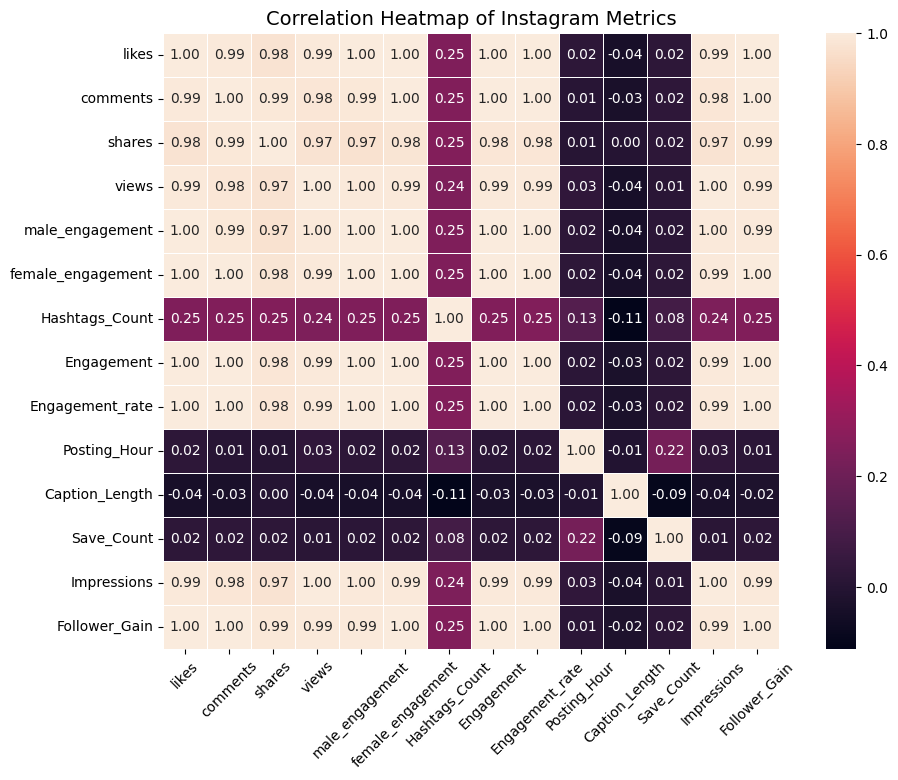

In [74]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar=True
)

plt.title("Correlation Heatmap of Instagram Metrics", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

### **Gender Engagement**

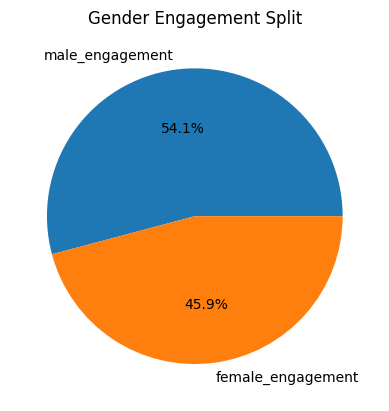

In [38]:
df[['male_engagement','female_engagement']].sum().plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Engagement Split")
plt.ylabel("")
plt.show()

###  **Average count**

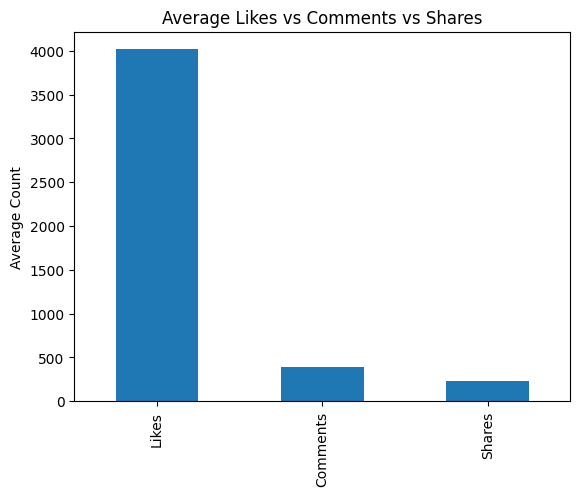

In [38]:
avg_values = df[['Likes','Comments','Shares']].mean()

avg_values.plot(kind='bar')
plt.title("Average Likes vs Comments vs Shares")
plt.ylabel("Average Count")
plt.show()

### **Viral post**

In [47]:
viral = df[df['views'] > 90000]
viral

,post_id,date,post_type,likes,comments,shares,views,male_engagement,female_engagement,Hashtags_Count,Engagement,Engagement_rate,Day,Month,Posting_Hour,Age_Group,Caption_Length,Save_Count,Impressions,Follower_Gain
99,P100,2025-10-29,reel,7500.0,600.0,2200.0,95000.0,4000.0,3500.0,21,10300.0,0.820064,Wednesday,October,12,25-34,55,196,95784.0,260.0
